# SMOTE synthesis in MIMIC image embedding space

Load a serialized dataset, a saved MIMIC model, and its embeddings. Select one embedding and its nearest neighbor, interpolate between them, decode the intermediate embedding, and display the resynthesized image.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "vision" / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ROOT_SRC = PROJECT_ROOT / "src"
VISION_SRC = PROJECT_ROOT / "vision" / "src"
for src_dir in [str(ROOT_SRC), str(VISION_SRC)]:
    if src_dir not in sys.path:
        sys.path.insert(0, src_dir)

from mimic import MIMIC
from mimic_vision import (
    load_serialized_vision_dataset,
    load_serialized_vision_embedding,
    plot_smote_differences,
    resolve_artifact_file,
    plot_smote_synthesis,
    select_embedding_neighbors,
    synthesize_smote_image,
)

In [3]:
DATASET_FILE = "last"  # Use "last" or an explicit dataset filename.
EMBEDDING_FILE = "last"  # Use "last" or an explicit embedding filename.
MODEL_FILE = "last"  # Use "last" or an explicit .joblib model filename.

DATASET_DIR = PROJECT_ROOT / "vision" / "data" / "serialized"
EMBEDDING_DIR = PROJECT_ROOT / "vision" / "data" / "embeddings"
MODEL_DIR = PROJECT_ROOT / "vision" / "data" / "models"

SOURCE_INDEX = None  # Set an integer to choose the first image manually.
NEIGHBOR_K = 20  # Choose the neighbor randomly among the k nearest non-self embeddings.
LAMBDA_VALUE = 0.5
DIFFERENCE_MODE = "signed"  # signed: white=no change, blue=SMOTE brighter, red=SMOTE darker.
RANDOM_STATE = 0
SIDE_LENGTH = 1.2
PLOT_SIZE = (SIDE_LENGTH, SIDE_LENGTH)  # Per-panel size;

In [4]:
dataset_path = resolve_artifact_file(DATASET_FILE, input_dir=DATASET_DIR, pattern="*.pkl")
DATASET_FILE = dataset_path.name
dataset = load_serialized_vision_dataset(dataset_path)

embedding_pattern = f"{Path(DATASET_FILE).stem}_mimic-*.pkl" if str(EMBEDDING_FILE).lower() == "last" else "*.pkl"
embedding_path = resolve_artifact_file(EMBEDDING_FILE, input_dir=EMBEDDING_DIR, pattern=embedding_pattern)
EMBEDDING_FILE = embedding_path.name

model_pattern = f"{Path(EMBEDDING_FILE).stem}.joblib" if str(MODEL_FILE).lower() == "last" else "*.joblib"
model_path = resolve_artifact_file(MODEL_FILE, input_dir=MODEL_DIR, pattern=model_pattern)
MODEL_FILE = model_path.name

embedding_artifact = load_serialized_vision_embedding(embedding_path)
model = MIMIC.load(model_path)

if embedding_artifact.dataset_file != DATASET_FILE:
    raise ValueError(f"Embedding artifact was created for {embedding_artifact.dataset_file}, not {DATASET_FILE}.")

DATASET_FILE, EMBEDDING_FILE, MODEL_FILE, dataset.X.shape, embedding_artifact.embeddings.shape

('mnist_train_n3200_classes-5-6-8-9_21x21.pkl',
 'mnist_train_n3200_classes-5-6-8-9_21x21_mimic-direct_cap0p2_emb11466.pkl',
 'mnist_train_n3200_classes-5-6-8-9_21x21_mimic-direct_cap0p2_emb11466.joblib',
 (3200, 441),
 (3200, 11466))

In [5]:
source_index, neighbor_index = select_embedding_neighbors(
    embedding_artifact.embeddings,
    source_index=SOURCE_INDEX,
    k=NEIGHBOR_K,
    random_state=None,
)
source_index, neighbor_index

(2789, 2784)

In [6]:
synthesis = synthesize_smote_image(
    model,
    embedding_artifact.embeddings,
    source_index=source_index,
    neighbor_index=neighbor_index,
    image_shape=dataset.image_shape,
    lambda_value=LAMBDA_VALUE,
)
synthesis.vector.shape, synthesis.image.shape

((441,), (21, 21))

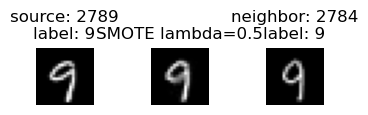

In [7]:
fig, axes = plot_smote_synthesis(
    dataset.images,
    synthesis,
    labels=dataset.y,
    target_names=dataset.target_names,
    size=PLOT_SIZE,
)

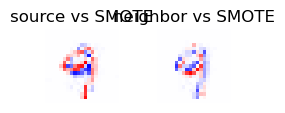

In [8]:
fig, axes = plot_smote_differences(
    dataset.images,
    synthesis,
    mode=DIFFERENCE_MODE,
    size=PLOT_SIZE,
)